In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    r"C:\Users\Dell\OneDrive\Desktop\Credit-Card-Fraud-Detection\data\creditcard.csv"
)

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

   

In [5]:
print("Shape:", df.shape)

Shape: (284807, 31)


In [6]:
print(df.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [7]:
print(df.dtypes)

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [8]:
print(df.isnull().sum().sum())

0


In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1081


In [15]:
df_clean = df.copy()

print("df_clean created successfully!")
print(df_clean.shape)

df_clean created successfully!
(284807, 31)


In [18]:
import numpy as np

df_clean["Amount_Log"] = np.log1p(df_clean["Amount"])

print("Amount_Log created successfully!")

Amount_Log created successfully!


In [19]:
print(df_clean[["Amount", "Amount_Log"]].head())

   Amount  Amount_Log
0  149.62    5.014760
1    2.69    1.305626
2  378.66    5.939276
3  123.50    4.824306
4   69.99    4.262539


ML PROBLEM 1
- Credit Card Fraud Classification
- Define X and y

In [21]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (284807, 31)
y shape: (284807,)


Train-Test Split

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (227845, 31)
Testing data: (56962, 31)


Logistic Regression

In [25]:
logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [26]:
logistic_pred = logistic_model.predict(X_test)

print(logistic_pred[:20])

[0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]


Classification Evaluation

In [29]:
print(classification_report(
    y_test,
    logistic_pred,
    zero_division=0
))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



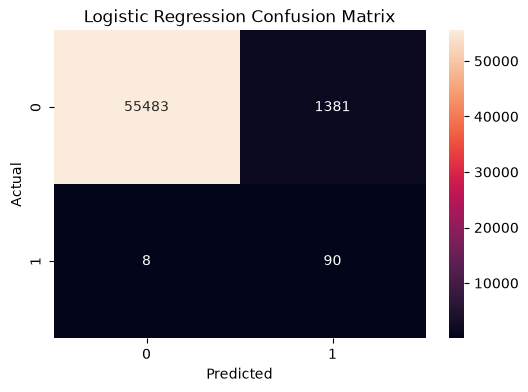

In [30]:
cm = confusion_matrix(y_test, logistic_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

ML PROBLEM 2
- Fraud Probability and Risk Scoring

In [33]:
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

print(logistic_prob[:10])

[5.98137979e-03 6.49336666e-02 1.38518057e-04 1.38013260e-02
 9.44196204e-01 1.31316677e-02 7.76570036e-04 2.60728950e-02
 6.51964159e-02 4.63467441e-03]


Risk Score

In [34]:
risk_output = pd.DataFrame({
    "Fraud_Probability": logistic_prob,
    "Actual_Class": y_test.values
})

print(risk_output.head())

   Fraud_Probability  Actual_Class
0           0.005981             0
1           0.064934             0
2           0.000139             0
3           0.013801             0
4           0.944196             0


Risk Levels

In [35]:
def risk_category(prob):
    if prob < 0.30:
        return "Low Risk"
    elif prob < 0.70:
        return "Medium Risk"
    else:
        return "High Risk"

risk_output["Risk_Level"] = (
    risk_output["Fraud_Probability"]
    .apply(risk_category)
)

print(risk_output.head())

   Fraud_Probability  Actual_Class Risk_Level
0           0.005981             0   Low Risk
1           0.064934             0   Low Risk
2           0.000139             0   Low Risk
3           0.013801             0   Low Risk
4           0.944196             0  High Risk


In [36]:
print(risk_output["Risk_Level"].value_counts())

Risk_Level
Low Risk       53651
Medium Risk     2594
High Risk        717
Name: count, dtype: int64
